# Visualize a CAD model with OCCWL

This notebook uses [OCCWL](https://github.com/AutodeskAILab/occwl), a Python wrapper around OpenCascade. Select the `occwl_viewer` kernel before running it.

The UV-Net MFCAD download in `data/MFCADDataset` contains preprocessed DGL graphs and labels, not the original STEP solids. The helper below downloads an original STEP file from the [MFCAD repository](https://github.com/hducg/MFCAD/tree/master/dataset/step) only when it is missing locally, caches it in `data/MFCADDataset/steps`, and displays it with OCCWL.

In [1]:
import os
from pathlib import Path
import re
import shutil
from urllib.parse import quote
from urllib.error import HTTPError, URLError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import networkx as nx
from occwl.compound import Compound
from occwl.graph import face_adjacency
from occwl.jupyter_viewer import JupyterViewer

MFCAD's preprocessed graph names end in `_color`, while the source STEP filenames do not. `download_mfcad_step` accepts either form.

In [2]:
MFCAD_STEP_BASE_URL = (
    "https://raw.githubusercontent.com/hducg/MFCAD/master/dataset/step"
)
MFCAD_STEPS_DIR = Path("../data/MFCADDataset/steps").resolve()


def download_mfcad_step(sample_id, steps_dir=MFCAD_STEPS_DIR):
    """Return a cached MFCAD STEP path, downloading it when necessary."""
    name = Path(str(sample_id)).name
    if name.endswith(".step"):
        name = name[:-5]
    if name.endswith("_color"):
        name = name[:-6]
    if re.fullmatch(r"[0-9-]+", name) is None:
        raise ValueError(f"Invalid MFCAD sample ID: {sample_id!r}")

    steps_dir = Path(steps_dir)
    steps_dir.mkdir(parents=True, exist_ok=True)
    step_path = steps_dir / f"{name}.step"
    if step_path.is_file():
        print(f"Using cached STEP: {step_path}")
        return step_path

    url = f"{MFCAD_STEP_BASE_URL}/{quote(step_path.name)}"
    partial_path = step_path.with_suffix(".step.part")
    print(f"Downloading {url}")
    try:
        with urlopen(url, timeout=60) as response, partial_path.open("wb") as file:
            shutil.copyfileobj(response, file)
        os.replace(partial_path, step_path)
    except (HTTPError, URLError) as error:
        partial_path.unlink(missing_ok=True)
        raise RuntimeError(
            f"Could not download MFCAD sample {name!r} from GitHub"
        ) from error
    return step_path


def plot_brep_graph(solid):
    """Plot the undirected face-adjacency graph of an OCCWL solid."""
    directed_graph = face_adjacency(solid)
    graph = nx.Graph(directed_graph)
    positions = nx.spring_layout(graph, seed=7)

    fig, ax = plt.subplots(figsize=(7, 6))
    nx.draw_networkx(
        graph,
        pos=positions,
        ax=ax,
        node_color="steelblue",
        edge_color="#555555",
        node_size=650,
        font_color="white",
        font_size=9,
        width=1.5,
    )
    ax.set_title("B-rep face-adjacency graph")
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()
    return graph


def draw_mfcad(sample_id):
    """Download, load, and display one MFCAD solid."""
    step_path = download_mfcad_step(sample_id)
    solids = list(Compound.load_from_step(step_path).solids())
    if not solids:
        raise ValueError(f"No solids found in {step_path}")

    solid = solids[0]
    print(f"Model: {step_path.name}")
    print(f"Faces: {len(list(solid.faces()))}")
    print(f"Edges: {len(list(solid.edges()))}")

    viewer = JupyterViewer()
    viewer.display(
        solid,
        shape_color="steelblue",
        edge_color="black",
        render_edges=True,
    )
    viewer.show()

    renderer = viewer._renderer
    grid_checkbox = renderer._controls[1]
    grid_checkbox.value = False

    return viewer, solid

Using cached STEP: /Users/yongjun/Workspace/NUS/CS5284/project/data/MFCADDataset/steps/0-0-10-12-19.step
Model: 0-0-10-12-19.step
Faces: 17
Edges: 42


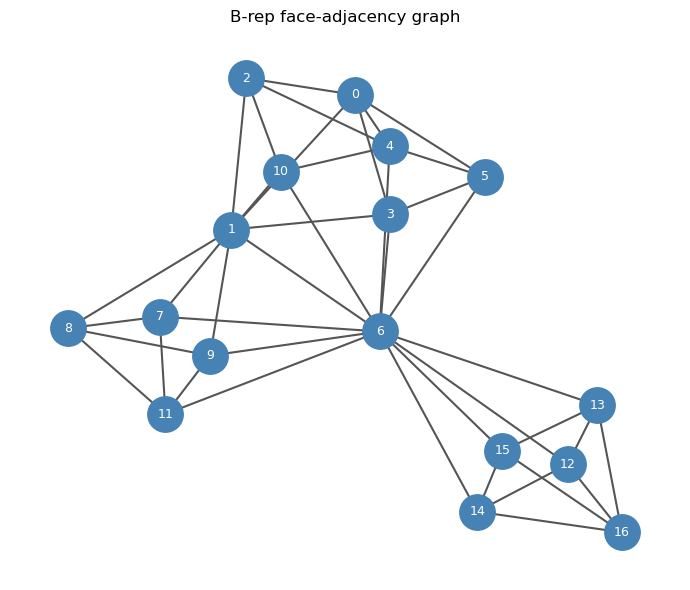

B-rep graph: 17 face nodes, 41 shared-edge adjacencies


TraitError: The 'rotation' trait of a GridHelper instance contains an Enum of an Euler which expected any of ['XYZ', 'YZX', 'ZXY', 'XZY', 'YXZ', 'ZYX'], not the str 'xyz'.

In [3]:
viewer, solid = draw_mfcad("0-0-10-12-19_color")
brep_graph = plot_brep_graph(solid)
print(
    f"B-rep graph: {brep_graph.number_of_nodes()} face nodes, "
    f"{brep_graph.number_of_edges()} shared-edge adjacencies"
)